In [ ]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

In [ ]:
!unzip fruits.zip

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
tf.__version__

'2.20.0'

In [ ]:
img_height, img_width = 32, 32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/train",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/validation",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/test",
    image_size = (img_height, img_width),
    batch_size = batch_size
)


Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


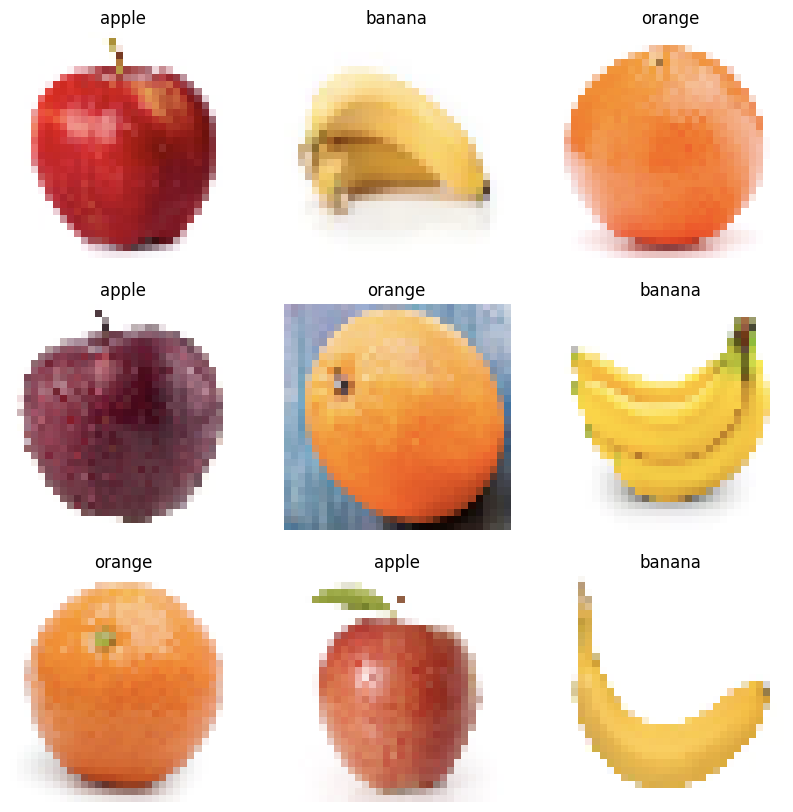

In [ ]:
class_names = ["apple", "banana", "orange"]
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="softmax"),
        tf.keras.layers.Dense(3)
    ]
)

In [ ]:
model.compile(
    optimizer="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=20)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.3413 - loss: 1.0953 - val_accuracy: 0.5455 - val_loss: 1.0811
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.4957 - loss: 1.0656 - val_accuracy: 0.4545 - val_loss: 1.0408
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5304 - loss: 1.0205 - val_accuracy: 0.6061 - val_loss: 0.9812
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6087 - loss: 0.9826 - val_accuracy: 0.5606 - val_loss: 0.9720
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6804 - loss: 0.9602 - val_accuracy: 0.5152 - val_loss: 0.9708
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.7065 - loss: 0.9454 - val_accuracy: 0.8182 - val_loss: 0.9209
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.7565 - loss: 0.9223 - val_accuracy: 0.7273 - val_loss: 0.9147
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8196 - loss: 0.8930 - val_accuracy: 0.6515 - 

In [ ]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9000 - loss: 0.6385


[0.6385251879692078, 0.8999999761581421]

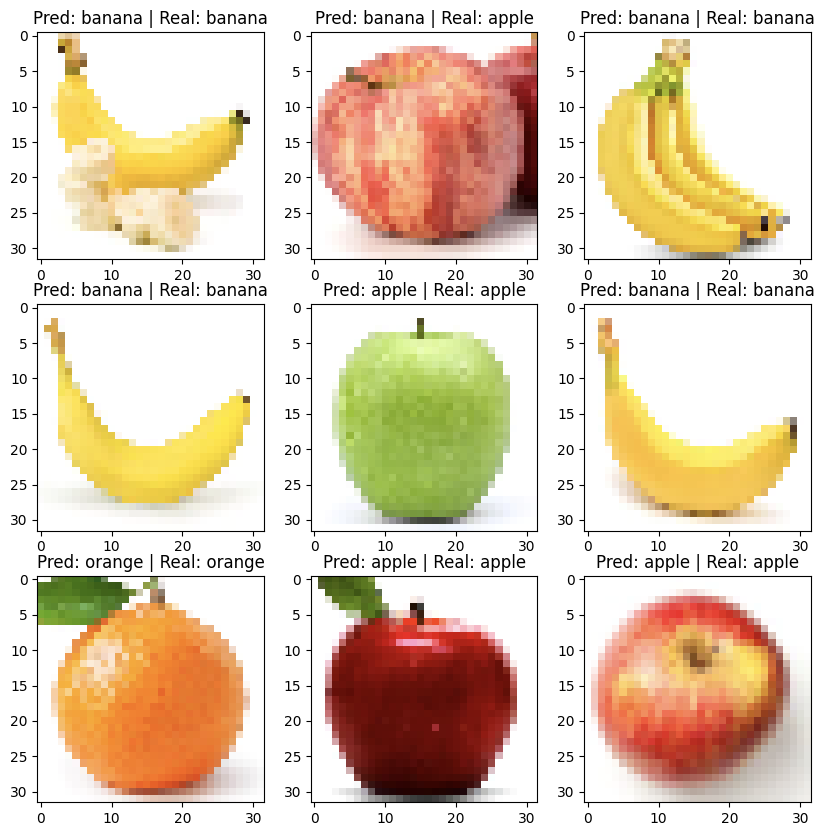

In [ ]:
import numpy

plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
  classifications = model(images)
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmp6fw96phd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140585427029648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140585427029264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140585427027728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140585427027536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140585427029456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140585427027344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140585427032912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140585427033296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140585427032720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140585427033488: TensorSpec(shape=(), dtype=tf.resource, name=None)
